In [163]:
%load_ext autoreload
%autoreload 2
import importlib 
hg = importlib.import_module(".model", "src")

m = importlib.import_module(".analytic-intersection-asymptotics", "src")
from matplotlib import pyplot as plt
import numpy as np
from scipy.special import binom
import xgi
import copy 
plt.style.use("seaborn-whitegrid")

from collections import defaultdict, Counter
import matplotlib as mpl
from matplotlib.colors import LinearSegmentedColormap, ListedColormap

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


/var/folders/xn/wvbwvw0d6dx46h9_2bkrknnw0000gn/T/ipykernel_29908/1788881870.py:12: MatplotlibDeprecationWarning: The seaborn styles shipped by Matplotlib are deprecated since 3.6, as they no longer correspond to the styles shipped by seaborn. However, they will remain available as 'seaborn-v0_8-<style>'. Alternatively, directly use the seaborn API instead.
  plt.style.use("seaborn-whitegrid")


### Parameters

In [164]:
k_max = 15
pars = {
    "eta"   : 0.4, 
    "beta"  : np.zeros(k_max),
    "gamma" : np.zeros(k_max)
}

pars["beta"][0:5] = 1/5
pars["gamma"][0:5] = 1/5

eta, beta, gamma = pars["eta"], pars["beta"], pars["gamma"]


### Build some simple simulations for comparison

In [165]:
timesteps = int(1e6)
H = hg.GrowingHypergraph()
H.add_edge((0, 1))
H.add_edge((2, 3))

max_size = 3
# r = np.zeros(shape=(max_size, max_size, max_size))
r = defaultdict(int)
r[(2, 2, 0)] = 1
save_r = []
edge_size_dict = defaultdict(int)
edge_size_dict[2] += 2


In [166]:
update_every = 100

R = np.zeros(shape = (timesteps // update_every, k_max), dtype = int)

# print(R.shape)

for cc in range(timesteps):
    e_ = H.sample_edge(eta, gamma, beta, True)
    eid = H.num_edges-1
    e_size = len(e_)    
    # update the size of r accordingly. it should always be max_size + 1
    # find all neighbors that have intersection with e_
    de = H.edge_neighborhood(eid, prior_only = True, as_node_sets = True)
    # count all the intersection sizes and add to r
    for nb in de:
        nb_size = len(nb)
        k = len(e_.intersection(nb))
        r[(e_size, nb_size, k)] += 1
        if nb_size != e_size:
            r[(nb_size, e_size, k)] += 1
        
    neighbor_sizes = [len(x) for x in de]
    nb_size_cnt = Counter(neighbor_sizes)
    for j, nj in edge_size_dict.items():
        # assert(nj >= nb_size_cnt[j])
        r[(j, e_size, 0)] += nj - nb_size_cnt[j]
        if j != e_size:
            r[(e_size, j, 0)] += nj - nb_size_cnt[j]

    if cc % update_every == 0:
        # print(cc)
        for k in range(k_max):
            R[cc//update_every, k] = sum([r[(i, j, k)] for i in range(k_max) for j in range(k_max)])
    edge_size_dict[e_size] += 1

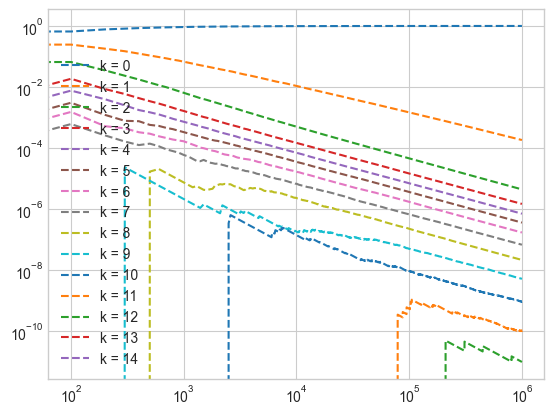

In [167]:
fig, ax = plt.subplots(1, 1)
R = R / R.sum(axis = 1)[:, None]
for k in range(k_max): 
    ax.plot(np.arange(timesteps // update_every)*update_every, R[:, k], label = f"k = {k}", linestyle = "--")

ax.loglog()
ax.legend()

### Linear Algebra Approximation

/Users/philchodrow/Desktop/HyperGraph/code/src/analytic-intersection-asymptotics.py:62: RuntimeWarning: invalid value encountered in divide
  S2_kyljh = binom(H, K)*binom(L - H, Y - K)/binom(L, Y)


[Text(0.5, 1.0, 'Sparsity: 0.990')]

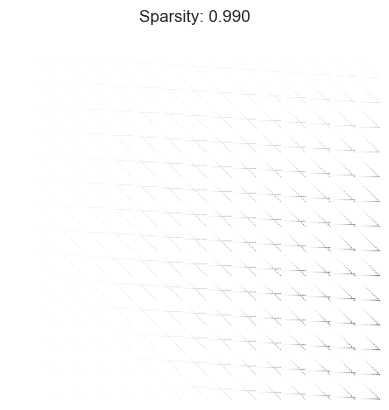

In [168]:
MC = m.MatrixConstructor(k_max, pars)
M = MC.matrix_of_linear_map()
plt.imshow(M > 0, vmin = 0, vmax = 1)
plt.gca().axis("off")
plt.gca().set(title = f"Sparsity: {(M == 0).mean():.3f}")

In [169]:
EV = np.linalg.eig(M)
# EV = np.linalg.eig(M.T)

# v = np.abs(EV[1][:, np.argmax(EV[0])])
print(f"Leading eigenvalue = {np.abs(EV[0][0]):.3f}")

Leading eigenvalue = 0.959


In [170]:
v = np.abs(EV[1][:, np.argmax(EV[0])])
T = m.vec_to_tensor(v, k_max)
T = T / T[:,:,0].sum()   

q = T.sum(axis = (0, 1))
q
# np.log(q)

array([1.00000000e+00, 1.76190795e+02, 4.28004433e+00, 1.46247853e+00,
       6.97623917e-01, 3.55328856e-01, 1.68786214e-01, 6.68071765e-02,
       2.11005979e-02, 5.13567702e-03, 9.13455775e-04, 1.05823584e-04,
       7.99999542e-06, 3.24937445e-07, 4.24992639e-09])

# Sample Asymptotics Plot

Eventually we want these curves to line up with the asymptotic lines, although obviously we are not there yet. 

[(100, 1000000),
 (2.229920460124318e-12, 5),
 Text(0.5, 0, 'Timestep $t$'),
 Text(0, 0.5, '$r_{k}(t)$')]

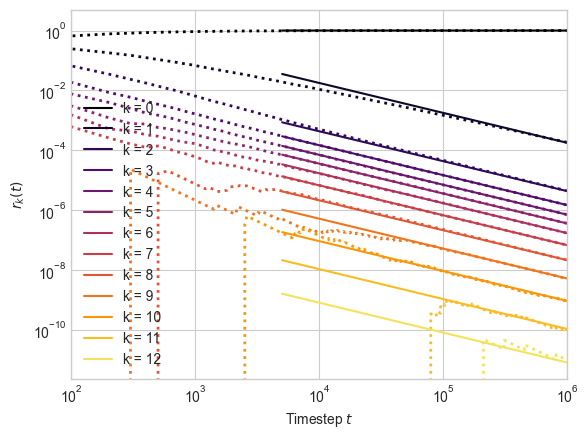

In [176]:
import matplotlib.cm as cm
cmap = cm.inferno

k_min = 0
show_k_up_to = 13

fig, ax = plt.subplots(1, 1)
R = R / R.sum(axis = 1)[:, None]
for k in range(k_min, show_k_up_to): 
    ax.plot(np.arange(timesteps // update_every)*(update_every), R[:, k], linestyle = ":", color = cmap(k/show_k_up_to), linewidth = 2)
    # ax.scatter(np.arange(timesteps // update_every)*(update_every), R[:, k],  color = cmap(k/show_k_up_to), facecolors = "none", s = 1)

# T = T / T[:,:,0].sum()   
# q = T.sum(axis = (0, 1))
# q = q / q.sum()
# np.log(q)

m_ = np.arange(50, 10000)*100 + 1

for k in range(k_min, show_k_up_to): 
    if k == 0: 
        ax.plot(q[k]*m_, np.ones_like(m_), label = f"k = {k}", color = cmap(k/show_k_up_to))
    else:    
        ax.plot(m_, q[k]*1/m_, label = f"k = {k}", color = cmap(k/show_k_up_to))

ax.loglog()
plt.legend()
ax.set(xlim = (100, timesteps), ylim = (None, 5), xlabel = r"Timestep $t$", ylabel = r"$r_{k}(t)$")



## Fun Viz of Matrix Sparsity

This would be a nice candidate for making an art piece to commemorate the project! 

/var/folders/xn/wvbwvw0d6dx46h9_2bkrknnw0000gn/T/ipykernel_29908/3185829134.py:16: RuntimeWarning: divide by zero encountered in log
  plt.imshow(np.log(M[k_max*(k_max+1):,k_max*(k_max+1):]), interpolation="none", cmap = "twilight")


(-0.5, 43.5, 43.5, -0.5)

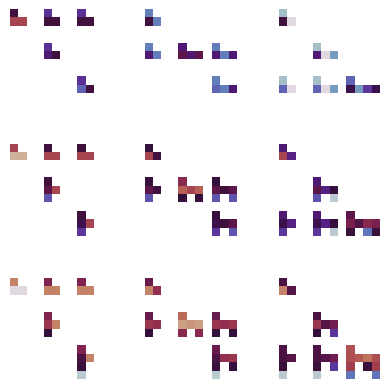

In [172]:
k_max = 4
pars = {
    "eta"   : 0.4, 
    "beta"  : np.zeros(k_max),
    "gamma" : np.zeros(k_max)
}

pars["beta"][0:5] = 1/5
pars["gamma"][0:5] = 1/5

eta, beta, gamma = pars["eta"], pars["beta"], pars["gamma"]


MC = m.MatrixConstructor(k_max, pars)
M = MC.matrix_of_linear_map()
plt.imshow(np.log(M[k_max*(k_max+1):,k_max*(k_max+1):]), interpolation="none", cmap = "twilight")
plt.gca().axis("off")
